Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xlrd
import openpyxl
from sklearn.impute import SimpleImputer 

Importing Data

In [2]:
data_frame = pd.read_excel("telcom_data.xlsx")


In [3]:
data_frame.head()

,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
0,13114483460844900352,2019-04-04 12:01:18,770.0,2019-04-25 14:35:31,662.0,1823652.0,2.082014e+14,3.366496e+10,3.552121e+13,9164566995485190,...,15854611.0,2501332.0,8198936.0,9656251.0,278082303.0,14344150.0,171744450.0,8814393.0,36749741.0,308879636.0
1,13114483482878900224,2019-04-09 13:04:04,235.0,2019-04-25 08:15:48,606.0,1365104.0,2.082019e+14,3.368185e+10,3.579401e+13,L77566A,...,20247395.0,19111729.0,18338413.0,17227132.0,608750074.0,1170709.0,526904238.0,15055145.0,53800391.0,653384965.0
2,13114483484080500736,2019-04-09 17:42:11,1.0,2019-04-25 11:58:13,652.0,1361762.0,2.082003e+14,3.376063e+10,3.528151e+13,D42335A,...,19725661.0,14699576.0,17587794.0,6163408.0,229584621.0,395630.0,410692588.0,4215763.0,27883638.0,279807335.0
3,13114483485442799616,2019-04-10 00:31:25,486.0,2019-04-25 07:36:35,171.0,1321509.0,2.082014e+14,3.375034e+10,3.535661e+13,T21824A,...,21388122.0,15146643.0,13994646.0,1097942.0,799538153.0,10849722.0,749039933.0,12797283.0,43324218.0,846028530.0
4,13114483499480700928,2019-04-12 20:10:23,565.0,2019-04-25 10:40:32,954.0,1089009.0,2.082014e+14,3.369980e+10,3.540701e+13,D88865A,...,15259380.0,18962873.0,17124581.0,415218.0,527707248.0,3529801.0,550709500.0,13910322.0,38542814.0,569138589.0


Shape of data

In [4]:
data_frame.shape

(150001, 55)

Verifying Data_types

In [5]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150001 entries, 0 to 150000
Data columns (total 55 columns):
 #   Column                                    Non-Null Count   Dtype         
---  ------                                    --------------   -----         
 0   Bearer Id                                 150001 non-null  object        
 1   Start                                     150000 non-null  datetime64[ns]
 2   Start ms                                  150000 non-null  float64       
 3   End                                       150000 non-null  datetime64[ns]
 4   End ms                                    150000 non-null  float64       
 5   Dur. (ms)                                 150000 non-null  float64       
 6   IMSI                                      149431 non-null  float64       
 7   MSISDN/Number                             148935 non-null  float64       
 8   IMEI                                      149429 non-null  float64       
 9   Last Location N

## Data Cleaning

Checking how much percentage of missing value each column have.

In [6]:
col_no_missing = []                      # empty list to store the column names which do not have missing values.
col_with_mfifty_missing = []             # empty list to store the column names which have missing values more than 50%.
col_with_lfifty_missing = []             # empty list to store the column names which have missing values less than 50%.

for col in data_frame.columns:
    missing_pct = data_frame[col].isnull().mean() * 100
    if missing_pct == 0.0:
        col_no_missing.append(col)
    elif missing_pct < 50:
        col_with_lfifty_missing.append(col)
    else:
        col_with_mfifty_missing.append(col)

print(f"Column with no missing values: {col_no_missing}")
print(f"Column with more than 50% missing values: {col_with_mfifty_missing}")
print(f"Column with less than 50% missing values: {col_with_lfifty_missing}")



Column with no missing values: ['Bearer Id', 'Social Media DL (Bytes)', 'Social Media UL (Bytes)', 'Google DL (Bytes)', 'Google UL (Bytes)', 'Email DL (Bytes)', 'Email UL (Bytes)', 'Youtube DL (Bytes)', 'Youtube UL (Bytes)', 'Netflix DL (Bytes)', 'Netflix UL (Bytes)', 'Gaming DL (Bytes)', 'Gaming UL (Bytes)', 'Other DL (Bytes)', 'Other UL (Bytes)']
Column with more than 50% missing values: ['TCP DL Retrans. Vol (Bytes)', 'TCP UL Retrans. Vol (Bytes)', 'HTTP DL (Bytes)', 'HTTP UL (Bytes)', 'Nb of sec with 125000B < Vol DL', 'Nb of sec with 1250B < Vol UL < 6250B', 'Nb of sec with 31250B < Vol DL < 125000B', 'Nb of sec with 37500B < Vol UL', 'Nb of sec with 6250B < Vol DL < 31250B', 'Nb of sec with 6250B < Vol UL < 37500B']
Column with less than 50% missing values: ['Start', 'Start ms', 'End', 'End ms', 'Dur. (ms)', 'IMSI', 'MSISDN/Number', 'IMEI', 'Last Location Name', 'Avg RTT DL (ms)', 'Avg RTT UL (ms)', 'Avg Bearer TP DL (kbps)', 'Avg Bearer TP UL (kbps)', 'DL TP < 50 Kbps (%)', '50 

Dropping columns with missing percentage more 50%

In [7]:
data_frame = data_frame.drop(columns=col_with_mfifty_missing)

Dataframe shape after dropping the columns

In [8]:
data_frame.shape

(150001, 45)

In [9]:
data_frame.head(5)

,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
0,13114483460844900352,2019-04-04 12:01:18,770.0,2019-04-25 14:35:31,662.0,1823652.0,2.082014e+14,3.366496e+10,3.552121e+13,9164566995485190,...,15854611.0,2501332.0,8198936.0,9656251.0,278082303.0,14344150.0,171744450.0,8814393.0,36749741.0,308879636.0
1,13114483482878900224,2019-04-09 13:04:04,235.0,2019-04-25 08:15:48,606.0,1365104.0,2.082019e+14,3.368185e+10,3.579401e+13,L77566A,...,20247395.0,19111729.0,18338413.0,17227132.0,608750074.0,1170709.0,526904238.0,15055145.0,53800391.0,653384965.0
2,13114483484080500736,2019-04-09 17:42:11,1.0,2019-04-25 11:58:13,652.0,1361762.0,2.082003e+14,3.376063e+10,3.528151e+13,D42335A,...,19725661.0,14699576.0,17587794.0,6163408.0,229584621.0,395630.0,410692588.0,4215763.0,27883638.0,279807335.0
3,13114483485442799616,2019-04-10 00:31:25,486.0,2019-04-25 07:36:35,171.0,1321509.0,2.082014e+14,3.375034e+10,3.535661e+13,T21824A,...,21388122.0,15146643.0,13994646.0,1097942.0,799538153.0,10849722.0,749039933.0,12797283.0,43324218.0,846028530.0
4,13114483499480700928,2019-04-12 20:10:23,565.0,2019-04-25 10:40:32,954.0,1089009.0,2.082014e+14,3.369980e+10,3.540701e+13,D88865A,...,15259380.0,18962873.0,17124581.0,415218.0,527707248.0,3529801.0,550709500.0,13910322.0,38542814.0,569138589.0


Handling columns with less than 50% missing values

In [10]:
print(f"Column names with > 50% missing values")
for col in col_with_lfifty_missing:
    print(f"{col}")

Column names with > 50% missing values
Start
Start ms
End
End ms
Dur. (ms)
IMSI
MSISDN/Number
IMEI
Last Location Name
Avg RTT DL (ms)
Avg RTT UL (ms)
Avg Bearer TP DL (kbps)
Avg Bearer TP UL (kbps)
DL TP < 50 Kbps (%)
50 Kbps < DL TP < 250 Kbps (%)
250 Kbps < DL TP < 1 Mbps (%)
DL TP > 1 Mbps (%)
UL TP < 10 Kbps (%)
10 Kbps < UL TP < 50 Kbps (%)
50 Kbps < UL TP < 300 Kbps (%)
UL TP > 300 Kbps (%)
Activity Duration DL (ms)
Activity Duration UL (ms)
Dur. (ms).1
Handset Manufacturer
Handset Type
Nb of sec with Vol DL < 6250B
Nb of sec with Vol UL < 1250B
Total UL (Bytes)
Total DL (Bytes)


Replacing missing values of numeric columns with median as median is robust to outliers - Median Imputation

In [11]:
numerical_cols = data_frame[col_with_lfifty_missing].select_dtypes(include='float64').columns
numerical_cols

Index(['Start ms', 'End ms', 'Dur. (ms)', 'IMSI', 'MSISDN/Number', 'IMEI',
       'Avg RTT DL (ms)', 'Avg RTT UL (ms)', 'Avg Bearer TP DL (kbps)',
       'Avg Bearer TP UL (kbps)', 'DL TP < 50 Kbps (%)',
       '50 Kbps < DL TP < 250 Kbps (%)', '250 Kbps < DL TP < 1 Mbps (%)',
       'DL TP > 1 Mbps (%)', 'UL TP < 10 Kbps (%)',
       '10 Kbps < UL TP < 50 Kbps (%)', '50 Kbps < UL TP < 300 Kbps (%)',
       'UL TP > 300 Kbps (%)', 'Activity Duration DL (ms)',
       'Activity Duration UL (ms)', 'Dur. (ms).1',
       'Nb of sec with Vol DL < 6250B', 'Nb of sec with Vol UL < 1250B',
       'Total UL (Bytes)', 'Total DL (Bytes)'],
      dtype='object')

In [12]:
imputer = SimpleImputer(strategy='median')
for col in numerical_cols:
    imputer.fit(data_frame[[col]])
    data_frame[[col]] = imputer.transform(data_frame[[col]])

Handling 'Start' and 'End' columns - Removing those rows which has missing values. 

In [13]:
data_frame = data_frame.dropna(subset=['Start','End'])

Replacing missing values of categorical columns with most frequent.

In [14]:
categorical_cols = data_frame[col_with_lfifty_missing].select_dtypes(include='object').columns
categorical_cols

Index(['Last Location Name', 'Handset Manufacturer', 'Handset Type'], dtype='object')

In [15]:
imputer1 = SimpleImputer(strategy='most_frequent')
for col in categorical_cols:
    imputer1.fit(data_frame[[col]])
    data_frame[[col]] = imputer1.transform(data_frame[[col]])

After imputation validating columns for missing values. 

In [16]:
data_frame.info()            # shows no missing values. 

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 0 to 149999
Data columns (total 45 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   Bearer Id                       150000 non-null  object        
 1   Start                           150000 non-null  datetime64[ns]
 2   Start ms                        150000 non-null  float64       
 3   End                             150000 non-null  datetime64[ns]
 4   End ms                          150000 non-null  float64       
 5   Dur. (ms)                       150000 non-null  float64       
 6   IMSI                            150000 non-null  float64       
 7   MSISDN/Number                   150000 non-null  float64       
 8   IMEI                            150000 non-null  float64       
 9   Last Location Name              150000 non-null  object        
 10  Avg RTT DL (ms)                 150000 non-null  float64     

Shape of DataFrame after imputation

In [17]:
data_frame.shape

(150000, 45)

Checking for Duplicate values

In [18]:
duplicate = data_frame.duplicated()
data_frame[duplicate]             # No duplicate rows in the data set

,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)


- Removing Duplicate columns - Dur. (ms).1

In [19]:
data_frame = data_frame.drop(columns=['Dur. (ms).1'])

## Top 10 handsets used by the customers

In [20]:
Top_ten_handsets_type = data_frame['Handset Type'].value_counts().head(10)
Top_ten_handsets_type

Handset Type
Huawei B528S-23A                20323
Apple iPhone 6S (A1688)          9419
Apple iPhone 6 (A1586)           9023
undefined                        8987
Apple iPhone 7 (A1778)           6326
Apple iPhone Se (A1723)          5187
Apple iPhone 8 (A1905)           4993
Apple iPhone Xr (A2105)          4568
Samsung Galaxy S8 (Sm-G950F)     4520
Apple iPhone X (A1901)           3813
Name: count, dtype: int64

## Top 3 handsets manufactures  

In [21]:
Top_three_handsets_manufactures = data_frame['Handset Manufacturer'].value_counts().head(3)
Top_three_handsets_manufactures

Handset Manufacturer
Apple      60136
Samsung    40839
Huawei     34423
Name: count, dtype: int64

## Top 5 handsets per top 3 handset manufacturer

In [22]:
Top_three_handsets_manufactures = Top_three_handsets_manufactures.index
print(Top_three_handsets_manufactures)   # Top three manufactures. 

Index(['Apple', 'Samsung', 'Huawei'], dtype='object', name='Handset Manufacturer')


In [23]:
df_Top_three_handsets_manufactures = data_frame[data_frame['Handset Manufacturer'].isin(Top_three_handsets_manufactures)]  # filtering top 3 handset manufacturer
df_Top_three_handsets_manufactures

,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
0,13114483460844900352,2019-04-04 12:01:18,770.0,2019-04-25 14:35:31,662.0,1823652.0,2.082014e+14,3.366496e+10,3.552121e+13,9164566995485190,...,15854611.0,2501332.0,8198936.0,9656251.0,278082303.0,14344150.0,171744450.0,8814393.0,36749741.0,308879636.0
1,13114483482878900224,2019-04-09 13:04:04,235.0,2019-04-25 08:15:48,606.0,1365104.0,2.082019e+14,3.368185e+10,3.579401e+13,L77566A,...,20247395.0,19111729.0,18338413.0,17227132.0,608750074.0,1170709.0,526904238.0,15055145.0,53800391.0,653384965.0
2,13114483484080500736,2019-04-09 17:42:11,1.0,2019-04-25 11:58:13,652.0,1361762.0,2.082003e+14,3.376063e+10,3.528151e+13,D42335A,...,19725661.0,14699576.0,17587794.0,6163408.0,229584621.0,395630.0,410692588.0,4215763.0,27883638.0,279807335.0
4,13114483499480700928,2019-04-12 20:10:23,565.0,2019-04-25 10:40:32,954.0,1089009.0,2.082014e+14,3.369980e+10,3.540701e+13,D88865A,...,15259380.0,18962873.0,17124581.0,415218.0,527707248.0,3529801.0,550709500.0,13910322.0,38542814.0,569138589.0
6,13114483501243799552,2019-04-13 08:41:59,612.0,2019-04-25 08:16:21,168.0,1035261.0,2.082014e+14,3.366537e+10,8.676270e+13,9164567010589190,...,7234465.0,1886295.0,13231006.0,17981760.0,44796223.0,14084934.0,803653557.0,10649768.0,47925246.0,70562047.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149994,13114483573367199744,2019-04-29 07:28:41,83.0,2019-04-30 15:01:06,268.0,113545.0,2.082003e+14,3.364566e+10,3.515541e+13,T88383B,...,23043782.0,19176074.0,18762809.0,9591310.0,810666072.0,14858904.0,777865837.0,14693970.0,59377936.0,862796008.0
149996,7277825670196679680,2019-04-29 07:28:42,451.0,2019-04-30 06:02:33,214.0,81230.0,2.082022e+14,3.365069e+10,3.548311e+13,D20434A,...,16191667.0,11763428.0,17883703.0,19678161.0,526609673.0,9197207.0,3264510.0,13487416.0,57628851.0,574175259.0
149997,7349883264234609664,2019-04-29 07:28:42,483.0,2019-04-30 10:41:33,187.0,97970.0,2.082019e+14,3.366345e+10,3.566051e+13,D10223C,...,13877234.0,8288284.0,19350146.0,21293148.0,626893062.0,4735033.0,712180387.0,2457758.0,39135081.0,666648844.0
149998,13114483573367300096,2019-04-29 07:28:43,283.0,2019-04-30 10:46:12,810.0,98249.0,2.082017e+14,3.362189e+10,3.572121e+13,T51102A,...,22660510.0,1855903.0,9963942.0,5065760.0,553539484.0,13394316.0,121100856.0,11314729.0,34912224.0,592786405.0


In [24]:
top_5_handsets_per_manufacture = df_Top_three_handsets_manufactures.groupby('Handset Manufacturer')['Handset Type'].value_counts().groupby(level=0).head(5)
top_5_handsets_per_manufacture

Handset Manufacturer  Handset Type                  
Apple                 Apple iPhone 6S (A1688)            9419
                      Apple iPhone 6 (A1586)             9023
                      Apple iPhone 7 (A1778)             6326
                      Apple iPhone Se (A1723)            5187
                      Apple iPhone 8 (A1905)             4993
Huawei                Huawei B528S-23A                  19752
                      Huawei E5180                       2079
                      Huawei P20 Lite Huawei Nova 3E     2021
                      Huawei P20                         1480
                      Huawei Y6 2018                      997
Samsung               Samsung Galaxy S8 (Sm-G950F)       4520
                      Samsung Galaxy A5 Sm-A520F         3724
                      Samsung Galaxy J5 (Sm-J530)        3696
                      Samsung Galaxy J3 (Sm-J330)        3484
                      Samsung Galaxy S7 (Sm-G930X)       3199
Name: count, dtyp

## Recommendation for the Marketing Team

-Apple dominates the handset ecosystem, accounting for the highest number of devices overall, with iPhone 6/6S/7 models still heavily used. This indicates a large base of mid‑to‑older iPhone users, suggesting strong brand loyalty despite device age.

-Samsung holds a strong second position, mainly driven by Galaxy S and A/J series, reflecting wide adoption across mid‑range and premium Android segments.

-Huawei ranks third, with a significant concentration around a single model (B528S‑23A), indicating device clustering and potential enterprise or fixed‑wireless usage patterns.

-The presence of “undefined” handsets among the top 10 suggests data quality gaps

# Task 1.1

a) Aggregate number of xDR sessions.

In [25]:
Agg_xDR = data_frame.groupby('MSISDN/Number')['Bearer Id'].count().reset_index(name='Number of xDR sessions')
Agg_xDR

,MSISDN/Number,Number of xDR sessions
0,3.360100e+10,1
1,3.360100e+10,1
2,3.360100e+10,1
3,3.360101e+10,1
4,3.360101e+10,2
...,...,...
106851,3.379000e+10,1
106852,3.379000e+10,1
106853,3.197021e+12,1
106854,3.370000e+14,1


b) Aggregate session duration 

In [26]:
Agg_session_dur = data_frame.groupby('MSISDN/Number')['Dur. (ms)'].sum().reset_index(name='Session Duration Per User(ms)')
Agg_session_dur

,MSISDN/Number,Session Duration Per User(ms)
0,3.360100e+10,116720.0
1,3.360100e+10,181230.0
2,3.360100e+10,134969.0
3,3.360101e+10,49878.0
4,3.360101e+10,37104.0
...,...,...
106851,3.379000e+10,8810.0
106852,3.379000e+10,140988.0
106853,3.197021e+12,877385.0
106854,3.370000e+14,253030.0


c)  Total download (DL) and upload (UL) data

In [27]:
TL_DL = data_frame.groupby('MSISDN/Number')['Total DL (Bytes)'].sum().reset_index(name='Total Download per User')
TL_DL

,MSISDN/Number,Total Download per User
0,3.360100e+10,8.426375e+08
1,3.360100e+10,1.207552e+08
2,3.360100e+10,5.566597e+08
3,3.360101e+10,4.019932e+08
4,3.360101e+10,1.363130e+09
...,...,...
106851,3.379000e+10,6.879252e+08
106852,3.379000e+10,4.445751e+08
106853,3.197021e+12,1.948281e+08
106854,3.370000e+14,5.396350e+08


In [28]:
TL_UL = data_frame.groupby('MSISDN/Number')['Total UL (Bytes)'].sum().reset_index(name='Total Upload per User')
TL_UL

,MSISDN/Number,Total Upload per User
0,3.360100e+10,36053108.0
1,3.360100e+10,36104459.0
2,3.360100e+10,39306820.0
3,3.360101e+10,20327526.0
4,3.360101e+10,94280527.0
...,...,...
106851,3.379000e+10,26716429.0
106852,3.379000e+10,35732243.0
106853,3.197021e+12,37295915.0
106854,3.370000e+14,56652839.0


d) total data volume (in Bytes) during this session for each application

- For social media

In [29]:
data_frame['Total_Social_Media_Bytes'] = data_frame['Social Media DL (Bytes)'] + data_frame['Social Media UL (Bytes)'] # creating new column to store the Total Bytes for Social Media


tsmb_per_user = data_frame.groupby('MSISDN/Number')['Total_Social_Media_Bytes'].sum().reset_index(name='Total Social Media data volume per user')
tsmb_per_user

,MSISDN/Number,Total Social Media data volume per user
0,3.360100e+10,2232135.0
1,3.360100e+10,2660565.0
2,3.360100e+10,3195623.0
3,3.360101e+10,280294.0
4,3.360101e+10,2912542.0
...,...,...
106851,3.379000e+10,300183.0
106852,3.379000e+10,498569.0
106853,3.197021e+12,715224.0
106854,3.370000e+14,521566.0


- For Google

In [30]:
data_frame['Total_Google_Bytes'] = data_frame['Google DL (Bytes)'] + data_frame['Google UL (Bytes)'] # creating new column to store the Total Bytes for Google


tgb_per_user = data_frame.groupby('MSISDN/Number')['Total_Google_Bytes'].sum().reset_index(name='Total Google data volume per user')
tgb_per_user

,MSISDN/Number,Total Google data volume per user
0,3.360100e+10,4389005.0
1,3.360100e+10,5334863.0
2,3.360100e+10,3443126.0
3,3.360101e+10,9678493.0
4,3.360101e+10,18499616.0
...,...,...
106851,3.379000e+10,7531269.0
106852,3.379000e+10,5429705.0
106853,3.197021e+12,10438660.0
106854,3.370000e+14,9830617.0


- Email

In [31]:
data_frame['Total_Email_Bytes'] = data_frame['Email DL (Bytes)'] + data_frame['Email UL (Bytes)'] # creating new column to store the Total Bytes for Email


teb_per_user = data_frame.groupby('MSISDN/Number')['Total_Email_Bytes'].sum().reset_index(name='Total Email data volume per user')
teb_per_user

,MSISDN/Number,Total Email data volume per user
0,3.360100e+10,1331362.0
1,3.360100e+10,3307781.0
2,3.360100e+10,3205380.0
3,3.360101e+10,2284670.0
4,3.360101e+10,3305469.0
...,...,...
106851,3.379000e+10,1006915.0
106852,3.379000e+10,2514097.0
106853,3.197021e+12,1520771.0
106854,3.370000e+14,3318582.0


- Youtube 

In [32]:
data_frame['Total_Youtube_Bytes'] = data_frame['Youtube DL (Bytes)'] + data_frame['Youtube UL (Bytes)'] # creating new column to store the Total Bytes for Youtube


tyb_per_user = data_frame.groupby('MSISDN/Number')['Total_Youtube_Bytes'].sum().reset_index(name='Total Youtube data volume per user')
tyb_per_user

,MSISDN/Number,Total Youtube data volume per user
0,3.360100e+10,21624548.0
1,3.360100e+10,12432223.0
2,3.360100e+10,21333570.0
3,3.360101e+10,6977321.0
4,3.360101e+10,41533002.0
...,...,...
106851,3.379000e+10,26647843.0
106852,3.379000e+10,19851572.0
106853,3.197021e+12,11959905.0
106854,3.370000e+14,36734940.0


- Netflix 

In [33]:
data_frame['Total_Netflix_Bytes'] = data_frame['Netflix DL (Bytes)'] + data_frame['Netflix UL (Bytes)'] # creating new column to store the Total Bytes for Netflix


tnb_per_user = data_frame.groupby('MSISDN/Number')['Total_Netflix_Bytes'].sum().reset_index(name='Total Netflix data volume per user')
tnb_per_user

,MSISDN/Number,Total Netflix data volume per user
0,3.360100e+10,27180981.0
1,3.360100e+10,11221763.0
2,3.360100e+10,19353900.0
3,3.360101e+10,1942092.0
4,3.360101e+10,49201724.0
...,...,...
106851,3.379000e+10,14902538.0
106852,3.379000e+10,8531060.0
106853,3.197021e+12,26592300.0
106854,3.370000e+14,30905042.0


- Gaming 

In [34]:
data_frame['Total_Gaming_Bytes'] = data_frame['Gaming DL (Bytes)'] + data_frame['Gaming UL (Bytes)'] # creating new column to store the Total Bytes for Gaming
data_frame['Total_Gaming_Bytes']

tgmb_per_user = data_frame.groupby('MSISDN/Number')['Total_Gaming_Bytes'].sum().reset_index(name='Total Gaming data volume per user')
tgmb_per_user

,MSISDN/Number,Total Gaming data volume per user
0,3.360100e+10,8.124587e+08
1,3.360100e+10,1.197501e+08
2,3.360100e+10,5.388277e+08
3,3.360101e+10,3.911261e+08
4,3.360101e+10,1.314798e+09
...,...,...
106851,3.379000e+10,6.603614e+08
106852,3.379000e+10,4.370033e+08
106853,3.197021e+12,1.780487e+08
106854,3.370000e+14,5.101427e+08


- Other 

In [35]:
data_frame['Total_Other_Bytes'] = data_frame['Other DL (Bytes)'] + data_frame['Other UL (Bytes)'] # creating new column to store the Total Bytes for Other
data_frame['Total_Other_Bytes']

tob_per_user = data_frame.groupby('MSISDN/Number')['Total_Other_Bytes'].sum().reset_index(name='Total Other data volume per user')
tob_per_user

,MSISDN/Number,Total Other data volume per user
0,3.360100e+10,386570872.0
1,3.360100e+10,281710071.0
2,3.360100e+10,501693672.0
3,3.360101e+10,35279702.0
4,3.360101e+10,804804484.0
...,...,...
106851,3.379000e+10,295282817.0
106852,3.379000e+10,211115113.0
106853,3.197021e+12,470526473.0
106854,3.370000e+14,149188439.0


# Task 1.2

a) Describe all relevant variables and associated data types

- Numerical Columns

In [36]:
Numerical_columns = data_frame.select_dtypes(include='float64').columns
Numerical_columns

Index(['Start ms', 'End ms', 'Dur. (ms)', 'IMSI', 'MSISDN/Number', 'IMEI',
       'Avg RTT DL (ms)', 'Avg RTT UL (ms)', 'Avg Bearer TP DL (kbps)',
       'Avg Bearer TP UL (kbps)', 'DL TP < 50 Kbps (%)',
       '50 Kbps < DL TP < 250 Kbps (%)', '250 Kbps < DL TP < 1 Mbps (%)',
       'DL TP > 1 Mbps (%)', 'UL TP < 10 Kbps (%)',
       '10 Kbps < UL TP < 50 Kbps (%)', '50 Kbps < UL TP < 300 Kbps (%)',
       'UL TP > 300 Kbps (%)', 'Activity Duration DL (ms)',
       'Activity Duration UL (ms)', 'Nb of sec with Vol DL < 6250B',
       'Nb of sec with Vol UL < 1250B', 'Social Media DL (Bytes)',
       'Social Media UL (Bytes)', 'Google DL (Bytes)', 'Google UL (Bytes)',
       'Email DL (Bytes)', 'Email UL (Bytes)', 'Youtube DL (Bytes)',
       'Youtube UL (Bytes)', 'Netflix DL (Bytes)', 'Netflix UL (Bytes)',
       'Gaming DL (Bytes)', 'Gaming UL (Bytes)', 'Other DL (Bytes)',
       'Other UL (Bytes)', 'Total UL (Bytes)', 'Total DL (Bytes)',
       'Total_Social_Media_Bytes', 'Total_Goog

- Categorical Columns

In [37]:
Categorical_columns = data_frame.select_dtypes(include='object').columns
Categorical_columns

Index(['Bearer Id', 'Last Location Name', 'Handset Manufacturer',
       'Handset Type'],
      dtype='object')

- Date and Time

In [38]:
Date_Time_columns = data_frame.select_dtypes(include='datetime64[ns]').columns
Date_Time_columns

Index(['Start', 'End'], dtype='object')

- Numerical Columns (float64)
The majority of variables in the dataset are stored as numerical (float64) types. These include session duration metrics, data usage volumes (DL/UL), throughput and latency indicators, percentage‑based KPIs, and application‑specific traffic measurements. These variables represent quantitative measures of user behavior and network performance and form the foundation for statistical analysis such as computing averages, dispersion, and usage patterns.
It is important to note that although all numerical variables are stored as float64, some columns (e.g., IMSI, MSISDN/Number, IMEI) represent identifiers rather than measurable quantities. These fields are treated as identifiers or categorical references in analysis and are excluded from statistical interpretation despite their numeric storage format.

- Categorical Columns (object)
Categorical variables include fields such as bearer identifiers, location names, handset manufacturers, and handset types. These columns describe qualitative attributes related to users, devices, and network context. They are primarily used for grouping, segmentation, and comparison across different user categories or device types rather than numerical computation

- Date‑Time Columns (datetime64[ns])
The dataset contains date‑time variables representing session start and end timestamps. These variables enable temporal analysis, such as understanding session timing, duration validation, and time‑based usage trends. They are essential for analyzing user behavior over time and correlating network performance with specific periods.

b) Analyze the basic metrics (mean, median, etc) in the Dataset (explain) & their importance for the global objective

In [39]:
Numerical_columns = Numerical_columns.drop(['IMSI', 'MSISDN/Number', 'IMEI'])  # removing 'IMSI', 'MSISDN/Number', 'IMEI' since these are identifier 
Numerical_columns

Index(['Start ms', 'End ms', 'Dur. (ms)', 'Avg RTT DL (ms)', 'Avg RTT UL (ms)',
       'Avg Bearer TP DL (kbps)', 'Avg Bearer TP UL (kbps)',
       'DL TP < 50 Kbps (%)', '50 Kbps < DL TP < 250 Kbps (%)',
       '250 Kbps < DL TP < 1 Mbps (%)', 'DL TP > 1 Mbps (%)',
       'UL TP < 10 Kbps (%)', '10 Kbps < UL TP < 50 Kbps (%)',
       '50 Kbps < UL TP < 300 Kbps (%)', 'UL TP > 300 Kbps (%)',
       'Activity Duration DL (ms)', 'Activity Duration UL (ms)',
       'Nb of sec with Vol DL < 6250B', 'Nb of sec with Vol UL < 1250B',
       'Social Media DL (Bytes)', 'Social Media UL (Bytes)',
       'Google DL (Bytes)', 'Google UL (Bytes)', 'Email DL (Bytes)',
       'Email UL (Bytes)', 'Youtube DL (Bytes)', 'Youtube UL (Bytes)',
       'Netflix DL (Bytes)', 'Netflix UL (Bytes)', 'Gaming DL (Bytes)',
       'Gaming UL (Bytes)', 'Other DL (Bytes)', 'Other UL (Bytes)',
       'Total UL (Bytes)', 'Total DL (Bytes)', 'Total_Social_Media_Bytes',
       'Total_Google_Bytes', 'Total_Email_Bytes', '

In [40]:
data_frame[Numerical_columns].describe()

,Start ms,End ms,Dur. (ms),Avg RTT DL (ms),Avg RTT UL (ms),Avg Bearer TP DL (kbps),Avg Bearer TP UL (kbps),DL TP < 50 Kbps (%),50 Kbps < DL TP < 250 Kbps (%),250 Kbps < DL TP < 1 Mbps (%),...,Other UL (Bytes),Total UL (Bytes),Total DL (Bytes),Total_Social_Media_Bytes,Total_Google_Bytes,Total_Email_Bytes,Total_Youtube_Bytes,Total_Netflix_Bytes,Total_Gaming_Bytes,Total_Other_Bytes
count,150000.000000,150000.000000,1.500000e+05,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,...,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05
mean,499.188200,498.800880,1.046086e+05,97.774807,15.315100,13300.045927,1770.428647,92.880673,3.053947,1.708720,...,8.264799e+06,4.112121e+07,4.546434e+08,1.828250e+06,7.807295e+06,2.259102e+06,2.264348e+07,2.262861e+07,4.303331e+08,4.293653e+08
std,288.611834,288.097653,8.103762e+04,559.911294,76.688249,23971.878541,4625.355500,13.015092,6.203407,4.150859,...,4.769020e+06,1.127639e+07,2.441429e+08,1.035650e+06,3.516432e+06,1.071113e+06,9.246831e+06,9.260851e+06,2.440207e+08,2.432689e+08
min,0.000000,0.000000,7.142000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.480000e+02,2.866892e+06,7.114041e+06,1.563000e+03,4.033000e+04,8.359000e+03,7.890300e+04,9.843200e+04,3.063580e+05,1.490450e+05
25%,250.000000,251.000000,5.744050e+04,35.000000,3.000000,43.000000,47.000000,91.000000,0.000000,0.000000,...,4.145904e+06,3.322201e+07,2.431068e+08,9.322132e+05,4.943592e+06,1.359343e+06,1.599846e+07,1.597944e+07,2.187274e+08,2.185509e+08
50%,499.000000,500.000000,8.639900e+04,45.000000,5.000000,63.000000,63.000000,100.000000,0.000000,0.000000,...,8.267086e+06,4.114331e+07,4.558411e+08,1.826442e+06,7.812852e+06,2.263574e+06,2.266181e+07,2.263559e+07,4.316152e+08,4.299923e+08
75%,749.000000,750.000000,1.324302e+05,62.000000,11.000000,19710.750000,1120.000000,100.000000,4.000000,1.000000,...,1.238420e+07,4.903424e+07,6.657055e+08,2.727489e+06,1.068285e+07,3.159825e+06,2.929266e+07,2.929060e+07,6.414161e+08,6.399281e+08
max,999.000000,999.000000,1.859336e+06,96923.000000,7120.000000,378160.000000,58613.000000,100.000000,93.000000,100.000000,...,1.655882e+07,7.833131e+07,9.029696e+08,3.650861e+06,1.552878e+07,4.518036e+06,4.519008e+07,4.519815e+07,8.592028e+08,8.595209e+08


Basic Metrics Analysis – Key Insights


- Session Duration:
Mean session duration is higher than the median, indicating a right‑skewed distribution where a small number of long sessions increase the average. Most users have moderate session lengths.


- Network Performance:
Median latency (RTT) and throughput values suggest generally acceptable network performance for typical users, while high variability and extreme maximum values highlight occasional poor network conditions.


- Throughput Distribution:
Percentage‑based throughput metrics show that many sessions operate in lower to mid throughput ranges, with fewer sessions achieving very high speeds. This indicates variability in user experience.


- Application Usage:
Streaming services (YouTube, Netflix) contribute significantly more to total data usage than Email or Social Media. Large standard deviations indicate diverse application usage patterns across users.


- Total Traffic Consumption:
Downlink traffic is substantially higher than uplink traffic, confirming download‑heavy user behavior. A small subset of users accounts for disproportionately high data consumption.


- Overall Insight:
The metrics reveal heterogeneous user behavior, dominance of streaming applications, and the presence of heavy users, supporting the objective of understanding user behavior and network usage patterns for capacity and performance planning.

c) Conduct a Non-Graphical Univariate Analysis by computing dispersion parameters for each quantitative variable and provide useful interpretation.


- Calculating IQR and then Range

In [41]:
Q1 = data_frame[Numerical_columns].quantile(0.25)
Q3 = data_frame[Numerical_columns].quantile(0.75)

IQR = Q3 - Q1
IQR 

Start ms                          4.990000e+02
End ms                            4.990000e+02
Dur. (ms)                         7.498975e+04
Avg RTT DL (ms)                   2.700000e+01
Avg RTT UL (ms)                   8.000000e+00
Avg Bearer TP DL (kbps)           1.966775e+04
Avg Bearer TP UL (kbps)           1.073000e+03
DL TP < 50 Kbps (%)               9.000000e+00
50 Kbps < DL TP < 250 Kbps (%)    4.000000e+00
250 Kbps < DL TP < 1 Mbps (%)     1.000000e+00
DL TP > 1 Mbps (%)                0.000000e+00
UL TP < 10 Kbps (%)               1.000000e+00
10 Kbps < UL TP < 50 Kbps (%)     0.000000e+00
50 Kbps < UL TP < 300 Kbps (%)    0.000000e+00
UL TP > 300 Kbps (%)              0.000000e+00
Activity Duration DL (ms)         6.647318e+05
Activity Duration UL (ms)         5.775555e+05
Nb of sec with Vol DL < 6250B     2.520000e+03
Nb of sec with Vol UL < 1250B     2.310000e+03
Social Media DL (Bytes)           1.795794e+06
Social Media UL (Bytes)           3.288600e+04
Google DL (By

In [42]:
Range = data_frame[Numerical_columns].max() - data_frame[Numerical_columns].min()
Range

Start ms                                999.0
End ms                                  999.0
Dur. (ms)                           1852194.0
Avg RTT DL (ms)                       96923.0
Avg RTT UL (ms)                        7120.0
Avg Bearer TP DL (kbps)              378160.0
Avg Bearer TP UL (kbps)               58613.0
DL TP < 50 Kbps (%)                     100.0
50 Kbps < DL TP < 250 Kbps (%)           93.0
250 Kbps < DL TP < 1 Mbps (%)           100.0
DL TP > 1 Mbps (%)                       94.0
UL TP < 10 Kbps (%)                     100.0
10 Kbps < UL TP < 50 Kbps (%)            98.0
50 Kbps < UL TP < 300 Kbps (%)          100.0
UL TP > 300 Kbps (%)                     96.0
Activity Duration DL (ms)         136536461.0
Activity Duration UL (ms)         144911293.0
Nb of sec with Vol DL < 6250B        604060.0
Nb of sec with Vol UL < 1250B        604121.0
Social Media DL (Bytes)             3586052.0
Social Media UL (Bytes)               65870.0
Google DL (Bytes)                 

1. Session and Activity Duration
The session and activity duration variables show high interquartile ranges (IQR) along with very large ranges. This indicates that while the middle 50% of users have moderately similar session durations, the difference between the shortest and longest sessions is extremely large.
Interpretation:
Most users spend a reasonable amount of time per session, but a small group of users stays connected for much longer periods, leading to high variability in session duration.

2. Network Performance Metrics (RTT and Throughput)
Network performance indicators such as round‑trip time (RTT) and bearer throughput display moderate IQR values but extremely large ranges. This means that typical users experience fairly consistent network performance, but there are rare cases where performance is either very poor or exceptionally high.
Interpretation:
For most users, network experience is stable; however, a few users face significant latency or throughput issues, causing wide variation in performance metrics.

3. Throughput Distribution Percentages
The throughput percentage variables generally have low IQR values, indicating that the middle group of users experiences similar throughput behavior. However, their large ranges suggest the presence of extreme cases.
Interpretation:
Most users fall into similar throughput categories, but occasional sessions experience very different throughput conditions, either extremely low or very high.

4. Application‑Level Data Usage
Application‑specific data usage variables (such as YouTube, Netflix, Gaming, and Other applications) show very high IQRs and extremely large ranges. This reflects substantial variation even among the middle 50% of users, along with very high maximum values.
Interpretation:
Data consumption varies widely among users, with a small number of users consuming very large volumes of data, particularly for streaming and gaming applications.

5. Total Uplink and Downlink Traffic
Total uplink and downlink traffic metrics exhibit significant dispersion, with downlink traffic showing a much larger IQR and range compared to uplink traffic.
Interpretation:
User behavior is predominantly download‑driven, and overall data consumption differs greatly between light users and heavy users, indicating strong heterogeneity in total network usage.

Overall Conclusion
The IQR and range analysis clearly shows that user behavior is highly heterogeneous. While most users demonstrate moderate and consistent usage patterns, a small subset of users contributes to extremely high session durations, data consumption, and network variability. This highlights the presence of heavy users and significant differences in user behavior across applications and network performance.

d) Conduct a Graphical Univariate Analysis by identifying the most suitable plotting options for each variable and interpreting your findings.

- Session / Activity Duration

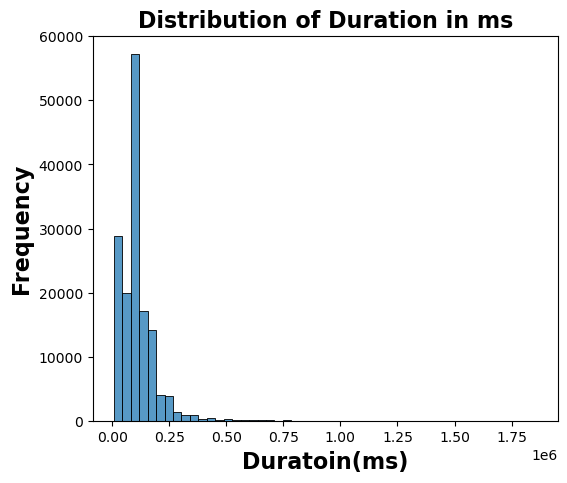

In [43]:
plt.figure(figsize=(6,5))
sns.histplot(data_frame['Dur. (ms)'],bins = 50)
plt.title('Distribution of Duration in ms',fontdict={'fontsize':16,'weight':'bold'})
plt.xlabel('Duratoin(ms)',fontdict={'fontsize':16,'weight':'bold'})
plt.ylabel('Frequency',fontdict={'fontsize':16,'weight':'bold'})
plt.show()

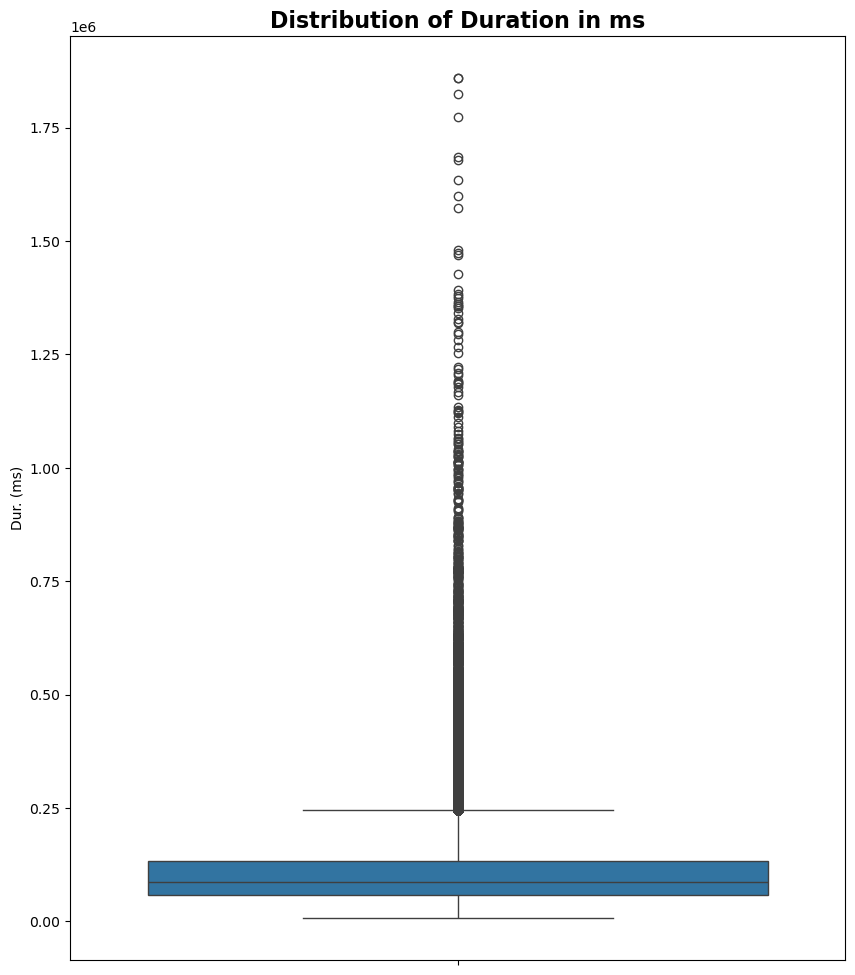

In [44]:
plt.figure(figsize=(10,12))
sns.boxplot(data_frame['Dur. (ms)'])
plt.title('Distribution of Duration in ms',fontdict={'fontsize':16,'weight':'bold'})
plt.show()

Interpretation: Session / Activity Duration (Dur. (ms)): The graphical univariate analysis reveals a right‑skewed distribution of session duration with several high‑value outliers, indicating that most users have moderate session lengths while a small group exhibits significantly longer sessions.

- Network Performance (Latency & Throughput)

-- Avg RTT DL (ms) --> for latency 

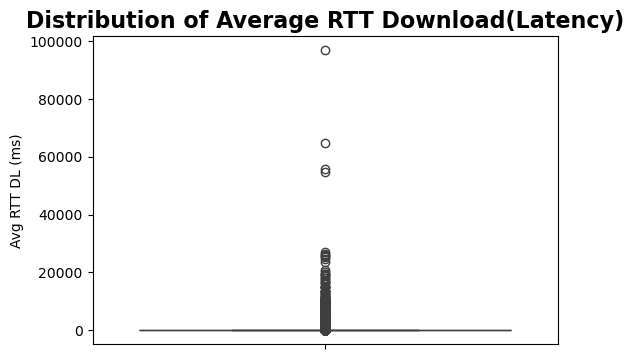

In [45]:
plt.figure(figsize=(6,4))
sns.boxplot(data_frame['Avg RTT DL (ms)'])
plt.title('Distribution of Average RTT Download(Latency)',fontdict={'fontsize':16,'weight':'bold'})
plt.show()

-- Avg Bearer TP DL (kbps) --> for throughput 

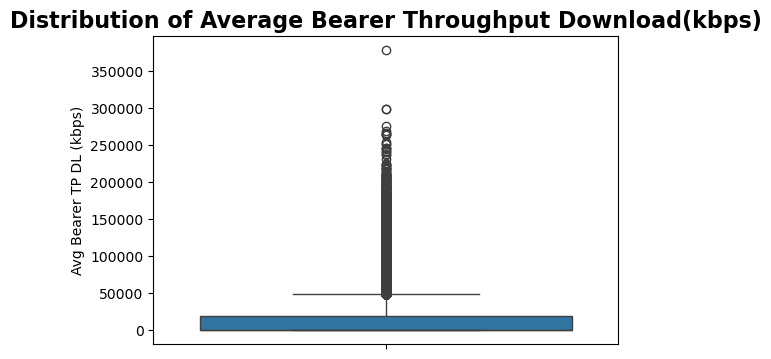

In [46]:
plt.figure(figsize=(6,4))
sns.boxplot(data_frame['Avg Bearer TP DL (kbps)'])
plt.title('Distribution of Average Bearer Throughput Download(kbps)',fontdict={'fontsize':16,'weight':'bold'})
plt.show()

Insight - The graphical univariate analysis shows that typical users experience stable latency and moderate throughput, while a small number of sessions exhibit extreme latency or very high download speeds, confirming heterogeneous network performance and user experience.

- Application‑Level Data Usage

-- Total_Youtube_Bytes

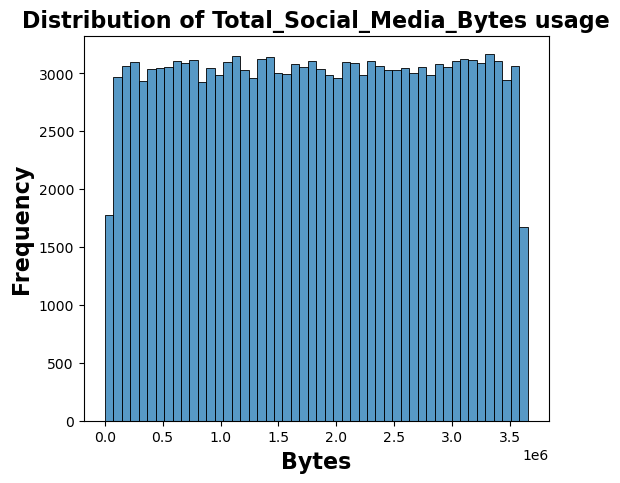

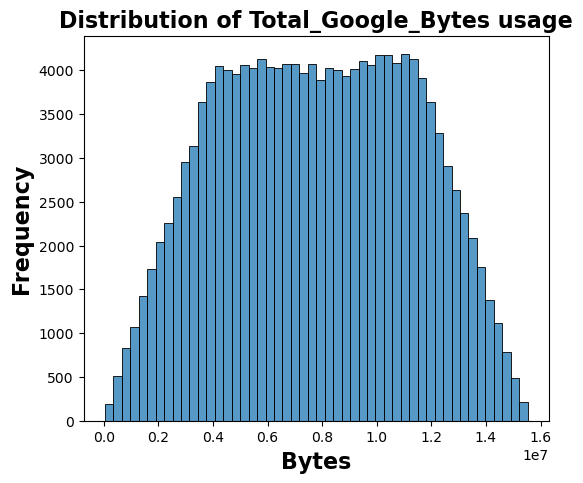

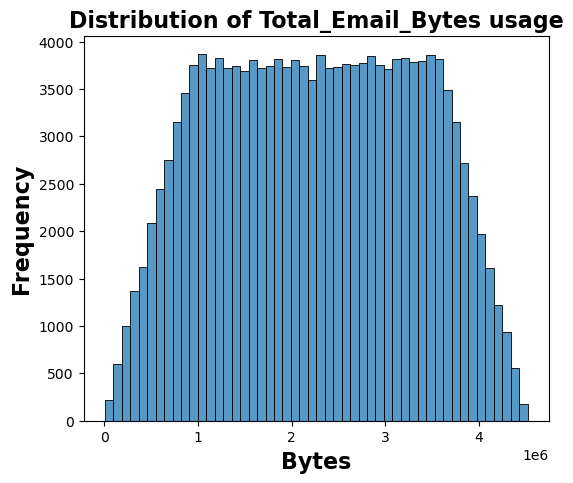

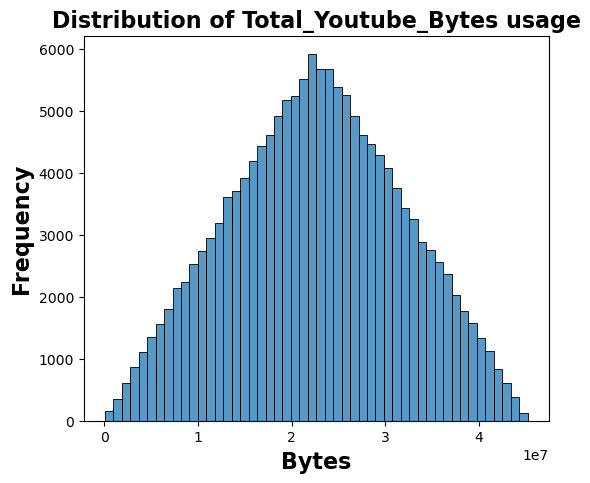

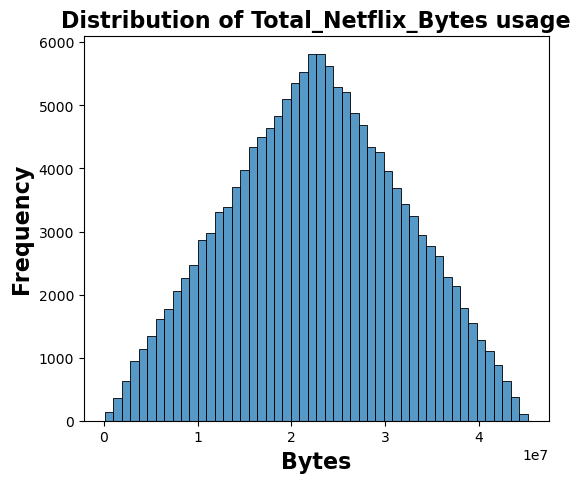

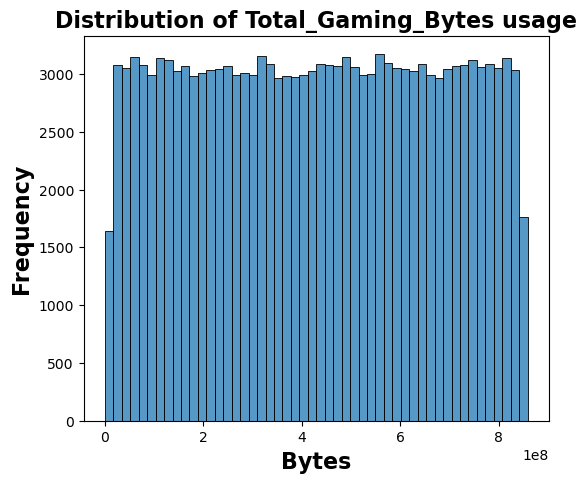

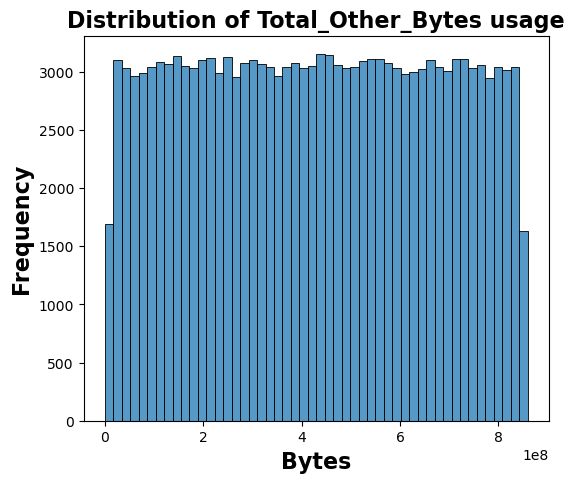

In [47]:
cols = ['Total_Social_Media_Bytes', 'Total_Google_Bytes', 'Total_Email_Bytes', 'Total_Youtube_Bytes', 'Total_Netflix_Bytes', 'Total_Gaming_Bytes', 'Total_Other_Bytes']
for col in cols:
     plt.figure(figsize=(6,5))
     sns.histplot(data_frame[col],bins = 50)
     plt.title(f'Distribution of {col} usage',fontdict={'fontsize':16,'weight':'bold'})
     plt.xlabel(f'Bytes',fontdict={'fontsize':16,'weight':'bold'})
     plt.ylabel('Frequency',fontdict={'fontsize':16,'weight':'bold'})
     plt.show()

Insight -


Social Media, Email, and Google usage show relatively evenly distributed usage patterns, indicating that most users consume similar amounts of data for these applications, with limited extreme behavior.


YouTube and Netflix usage display a more pronounced peak with wide spread, suggesting that while many users consume moderate amounts of streaming content, a notable proportion engages in high‑volume streaming, leading to increased variability.


Gaming and Other applications exhibit the widest spread and highest data volumes, indicating significant heterogeneity in usage. These categories are dominated by a small subset of users who consume disproportionately large amounts of data.

- Total Traffic 

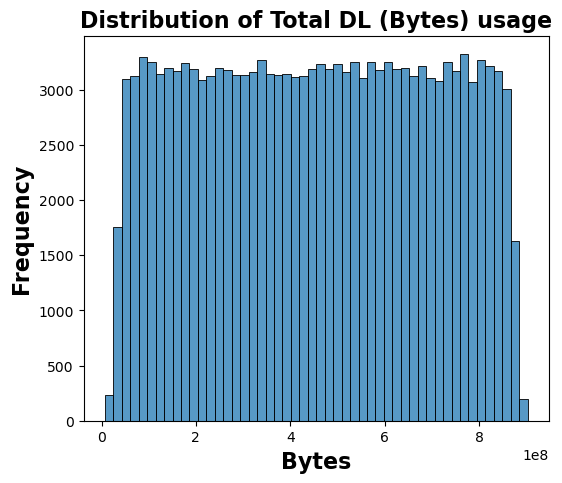

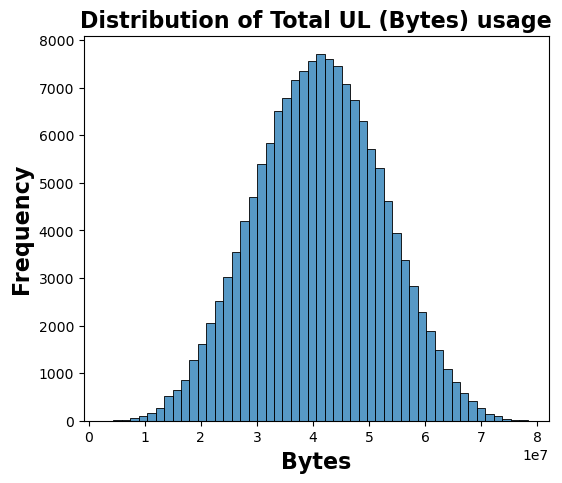

In [48]:
cols = ['Total DL (Bytes)','Total UL (Bytes)']
for col in cols:
     plt.figure(figsize=(6,5))
     sns.histplot(data_frame[col],bins = 50)
     plt.title(f'Distribution of {col} usage',fontdict={'fontsize':16,'weight':'bold'})
     plt.xlabel(f'Bytes',fontdict={'fontsize':16,'weight':'bold'})
     plt.ylabel('Frequency',fontdict={'fontsize':16,'weight':'bold'})
     plt.show()

Insight - These plots confirm that download traffic dominates overall data consumption and exhibits much higher variability than upload traffic. While upload usage patterns are relatively stable among users, download behavior varies widely, driven by activities such as streaming, browsing, and content consumption. This reinforces the presence of heterogeneous user behavior, with heavy download users contributing disproportionately to total network traffic.

e) Bivariate Analysis – explore the relationship between each application & the total DL+UL data using appropriate methods and interpret your findings

In [49]:
data_frame['Total_DL_UL'] = data_frame['Total UL (Bytes)'] + data_frame['Total DL (Bytes)'] # creating new column to have a total UL + DL
data_frame['Total_DL_UL']

0         345629377.0
1         707185356.0
2         307690973.0
3         889352748.0
4         607681403.0
             ...     
149995    872761860.0
149996    631804110.0
149997    705783925.0
149998    627698629.0
149999    401522016.0
Name: Total_DL_UL, Length: 150000, dtype: float64

- Checking skewness for 'Total_Social_Media_Bytes', 'Total_Google_Bytes', 'Total_Email_Bytes', 'Total_Youtube_Bytes', 'Total_Netflix_Bytes', 'Total_Gaming_Bytes', 'Total_Other_Bytes' and 'Total_DL_UL'

In [ ]:
columns = ['Total_Social_Media_Bytes', 'Total_Google_Bytes', 'Total_Email_Bytes', 'Total_Youtube_Bytes', 'Total_Netflix_Bytes', 'Total_Gaming_Bytes', 'Total_Other_Bytes', 'Total_DL_UL']
for col in columns:
    skew = data_frame[col].skew()
    print(f"Skewness of {col}: {skew}")

Skewness of Total_Social_Media_Bytes: -0.0021212509066101132
Skewness of Total_Google_Bytes: -0.010602007487386817
Skewness of Total_Email_Bytes: -0.006033102016886185
Skewness of Total_Youtube_Bytes: -0.005464925011984588
Skewness of Total_Netflix_Bytes: -0.0004094906902569855
Skewness of Total_Gaming_Bytes: -0.003224873971278654
Skewness of Total_Other_Bytes: 0.0012563373743434995
Skewness of Total_DL_UL: -0.002457315989359873


- Insight -> Skewness analysis shows that all application-level usage variables and total DL+UL usage have skewness values close to zero, indicating approximately symmetric distributions. Therefore, no log or square‑root transformation was required.

- Each application vs Total DL+UL 

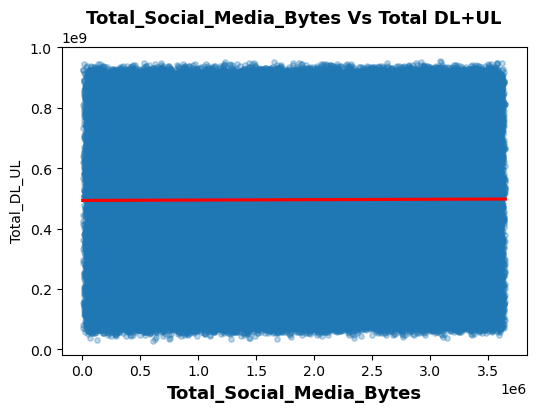

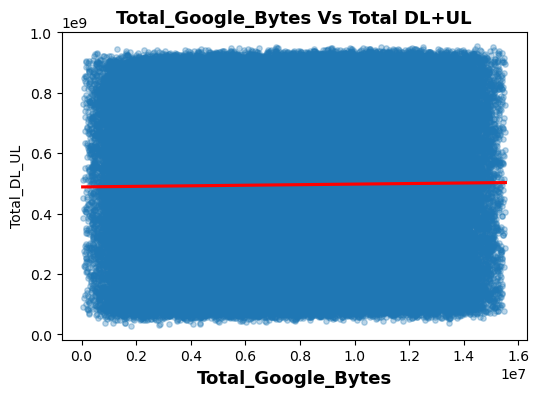

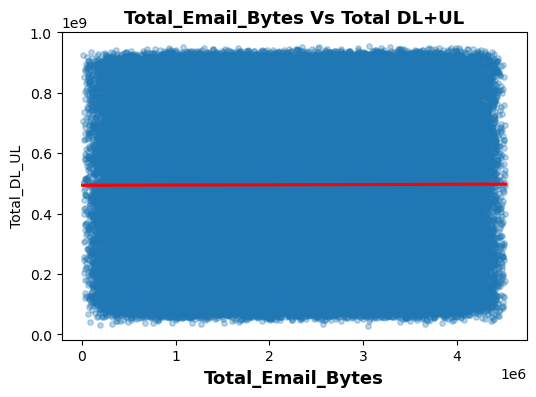

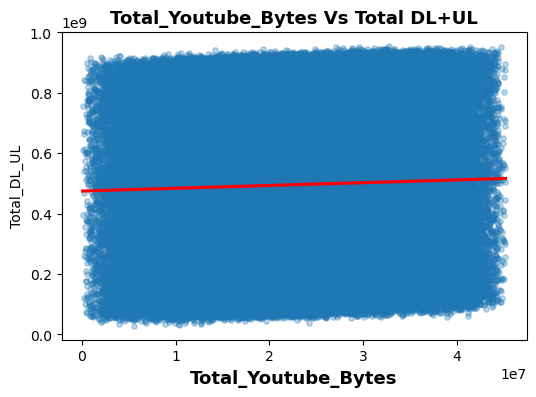

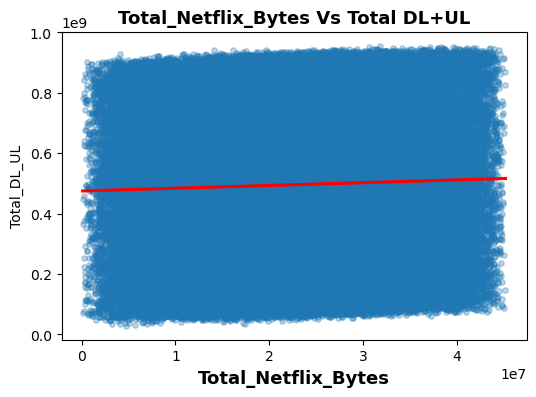

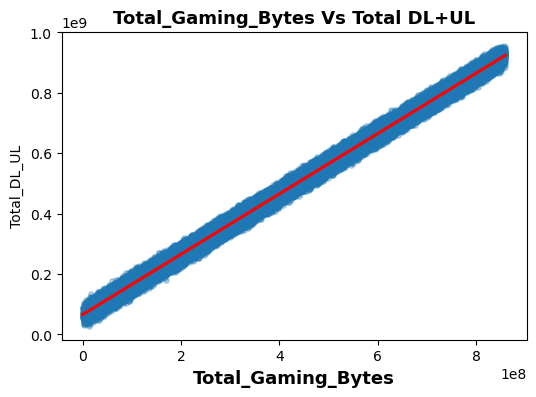

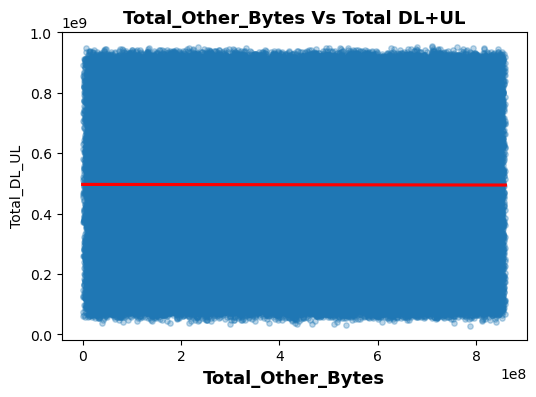

In [58]:
columns = ['Total_Social_Media_Bytes', 'Total_Google_Bytes', 'Total_Email_Bytes', 'Total_Youtube_Bytes', 'Total_Netflix_Bytes', 'Total_Gaming_Bytes', 'Total_Other_Bytes']
for col in columns:
    plt.figure(figsize=(6,4))
    sns.regplot(data=data_frame,x=col,y='Total_DL_UL',scatter_kws={'alpha':0.3, 's':15},line_kws={'color': 'red'},ci=None)
    plt.title(f'{col} Vs Total DL+UL',fontdict={'fontsize':13, 'weight':'bold'})
    plt.xlabel(f"{col}",fontdict={'fontsize':13, 'weight':'bold'})
    plt.show()

- Interpretation - Overall, bivariate analysis reveals that while all application categories exhibit a positive association with total DL+UL data usage, video streaming (YouTube and Netflix) and gaming applications display the strongest relationships. These applications are the primary contributors to total network traffic, whereas social media, email, Google, and other applications have a comparatively lower impact on overall data usage.

f) Variable transformations – segment the users into the top five decile classes based on the total duration for all sessions and compute the total data (DL+UL) per decile class.

In [62]:
user_level_df = (
    data_frame.pivot_table(
        index = 'MSISDN/Number',
        values= ['Dur. (ms)','Total_DL_UL'],
        aggfunc= {'Dur. (ms)':'sum','Total_DL_UL':'sum'}

    )
    .reset_index()
)
user_level_df.head()

,MSISDN/Number,Dur. (ms),Total_DL_UL
0,3.360100e+10,116720.0,8.786906e+08
1,3.360100e+10,181230.0,1.568596e+08
2,3.360100e+10,134969.0,5.959665e+08
3,3.360101e+10,49878.0,4.223207e+08
4,3.360101e+10,37104.0,1.457411e+09


In [65]:
# Create decile classes based on total session duration
user_level_df['Duration_Decile'] = pd.qcut(
    user_level_df['Dur. (ms)'],
    q=10,
    labels=[1,2,3,4,5,6,7,8,9,10]
)

user_level_df[['MSISDN/Number', 'Dur. (ms)', 'Duration_Decile']].head()


,MSISDN/Number,Dur. (ms),Duration_Decile
0,3.360100e+10,116720.0,6
1,3.360100e+10,181230.0,8
2,3.360100e+10,134969.0,7
3,3.360101e+10,49878.0,2
4,3.360101e+10,37104.0,2


In [66]:
# Top 5 decile.
top_five_decile = user_level_df[user_level_df['Duration_Decile'].astype(int) >= 6]
top_five_decile

,MSISDN/Number,Dur. (ms),Total_DL_UL,Duration_Decile
0,3.360100e+10,116720.0,8.786906e+08,6
1,3.360100e+10,181230.0,1.568596e+08,8
2,3.360100e+10,134969.0,5.959665e+08,7
5,3.360101e+10,253983.0,6.152172e+08,9
6,3.360101e+10,128360.0,6.547231e+08,6
...,...,...,...,...
106850,3.378998e+10,210389.0,1.094693e+09,9
106852,3.379000e+10,140988.0,4.803073e+08,7
106853,3.197021e+12,877385.0,2.321240e+08,10
106854,3.370000e+14,253030.0,5.962878e+08,9


In [70]:

decile_data_usage = (
    top_five_decile
    .groupby('Duration_Decile')['Total_DL_UL']
    .sum()
    .reset_index(name='Total_DL_UL_Bytes')
)

decile_data_usage


C:\Users\simranbhatti\AppData\Local\Temp\ipykernel_3612\1923107233.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Duration_Decile')['Total_DL_UL']


,Duration_Decile,Total_DL_UL_Bytes
0,1,0.000000e+00
1,2,0.000000e+00
2,3,0.000000e+00
3,4,0.000000e+00
4,5,0.000000e+00
5,6,6.426412e+12
6,7,6.152100e+12
7,8,7.822234e+12
8,9,9.306258e+12
9,10,1.539463e+13


In [72]:
# Converting Total DL UL Bytes to GB
decile_data_usage['Total_DL_UL_GB'] = (decile_data_usage['Total_DL_UL_Bytes'] / (1024 **3))
decile_data_usage['Total_DL_UL_GB'].reset_index()

,index,Total_DL_UL_GB
0,0,0.000000
1,1,0.000000
2,2,0.000000
3,3,0.000000
4,4,0.000000
5,5,5985.062307
6,6,5729.589325
7,7,7285.023306
8,8,8667.128382
9,9,14337.366697


- Interpetation : Users were segmented into decile classes based on their total session duration. Analysis of the top five deciles shows a strong increasing trend in total DL+UL data consumption with higher decile levels. Notably, the highest decile contributes a disproportionately large share of total data usage, indicating that a small group of highly engaged users drives the majority of network traffic.

g) Correlation Analysis – compute a correlation matrix for the following variables and interpret your findings: Social Media data, Google data, Email data, YouTube data, Netflix data, Gaming data, and Other data

In [77]:
columns = ['Total_Social_Media_Bytes', 'Total_Google_Bytes', 'Total_Email_Bytes', 'Total_Youtube_Bytes', 'Total_Netflix_Bytes', 'Total_Gaming_Bytes', 'Total_Other_Bytes']

correlation = data_frame[columns].corr()
correlation.reset_index()

,index,Total_Social_Media_Bytes,Total_Google_Bytes,Total_Email_Bytes,Total_Youtube_Bytes,Total_Netflix_Bytes,Total_Gaming_Bytes,Total_Other_Bytes
0,Total_Social_Media_Bytes,1.000000,-0.001708,0.004032,0.000548,0.001013,0.001082,0.006065
1,Total_Google_Bytes,-0.001708,1.000000,-0.000412,0.002277,-0.001902,-0.000994,-0.001727
2,Total_Email_Bytes,0.004032,-0.000412,1.000000,-0.002919,0.001029,-0.000644,-0.001299
3,Total_Youtube_Bytes,0.000548,0.002277,-0.002919,1.000000,0.002882,-0.002999,0.002969
4,Total_Netflix_Bytes,0.001013,-0.001902,0.001029,0.002882,1.000000,-0.003109,-0.009033
5,Total_Gaming_Bytes,0.001082,-0.000994,-0.000644,-0.002999,-0.003109,1.000000,-0.002661
6,Total_Other_Bytes,0.006065,-0.001727,-0.001299,0.002969,-0.009033,-0.002661,1.000000


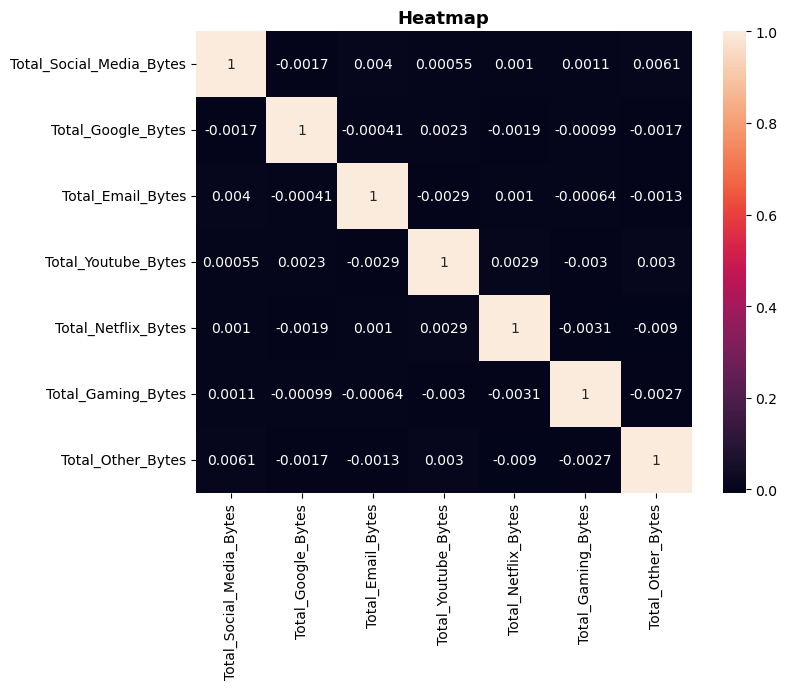

In [78]:
# Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True)
plt.title('Heatmap',fontdict={'fontsize':13,'weight':'bold'})
plt.show()

Interpetation : The correlation matrix shows very weak correlations among application-level data usage variables, with most correlation coefficients close to zero. This indicates minimal linear dependency between different applications, suggesting that usage of one application does not strongly influence usage of another. Overall, the results imply largely independent usage patterns across application categories, with users tending to consume specific types of services rather than all applications uniformly.